In [1]:
# ============================================================
# TASK 4 - Data Storytelling & Statistical Validation
# Project: E-Commerce Order Fulfillment Efficiency (Olist)
# ============================================================

from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv


In [2]:
# --- Load the uploaded files ---
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Reviews:", reviews.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Reviews: (99224, 7)


In [3]:
# --- Convert date columns ---
date_cols_orders = ['order_purchase_timestamp', 'order_approved_at',
                    'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col])

# --- Filter only delivered orders ---
df_delivered = orders[orders['order_status'] == 'delivered'].copy()

# --- Remove rows with missing delivery dates ---
df_delivered = df_delivered.dropna(subset=['order_delivered_customer_date',
                                            'order_estimated_delivery_date'])

# --- Calculate key columns ---
df_delivered['actual_delivery_days'] = (
    df_delivered['order_delivered_customer_date'] -
    df_delivered['order_purchase_timestamp']).dt.days

df_delivered['estimated_delivery_days'] = (
    df_delivered['order_estimated_delivery_date'] -
    df_delivered['order_purchase_timestamp']).dt.days

df_delivered['delivery_delay_days'] = (
    df_delivered['order_delivered_customer_date'] -
    df_delivered['order_estimated_delivery_date']).dt.days

# --- Flag late orders (delay > 0 means late) ---
df_delivered['is_late'] = df_delivered['delivery_delay_days'] > 0

# --- Merge with reviews ---
df = df_delivered.merge(reviews[['order_id', 'review_score']],
                        on='order_id', how='inner')

print("Final dataset shape:", df.shape)
print("\nLate orders:", df['is_late'].sum())
print("On-time orders:", (~df['is_late']).sum())
print("\nAvg review score - Late orders:", round(df[df['is_late']]['review_score'].mean(), 2))
print("Avg review score - On-time orders:", round(df[~df['is_late']]['review_score'].mean(), 2))

Final dataset shape: (96353, 13)

Late orders: 6409
On-time orders: 89944

Avg review score - Late orders: 2.27
Avg review score - On-time orders: 4.29


In [4]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# --- Separate the two groups ---
late_scores = df[df['is_late']]['review_score']
ontime_scores = df[~df['is_late']]['review_score']

# --- Perform Independent T-Test ---
t_stat, p_value = stats.ttest_ind(late_scores, ontime_scores)

print("=" * 50)
print("HYPOTHESIS TEST RESULTS")
print("=" * 50)
print(f"\nNull Hypothesis (H0): Late and on-time deliveries")
print(f"have NO significant difference in review scores.")
print(f"\nAlternative Hypothesis (H1): Late deliveries have")
print(f"significantly LOWER review scores.")
print(f"\n--- Results ---")
print(f"T-statistic     : {t_stat:.4f}")
print(f"P-value         : {p_value:.2e}")
print(f"\nAvg Score (Late)   : {late_scores.mean():.2f}")
print(f"Avg Score (On-time): {ontime_scores.mean():.2f}")
print(f"Difference         : {ontime_scores.mean() - late_scores.mean():.2f} points")
print("=" * 50)

if p_value < 0.05:
    print("\n✅ CONCLUSION: We REJECT the null hypothesis.")
    print("Late deliveries cause significantly lower review scores.")
    print("This finding is statistically significant (p < 0.05).")
else:
    print("\n❌ CONCLUSION: We FAIL to reject the null hypothesis.")

HYPOTHESIS TEST RESULTS

Null Hypothesis (H0): Late and on-time deliveries
have NO significant difference in review scores.

Alternative Hypothesis (H1): Late deliveries have
significantly LOWER review scores.

--- Results ---
T-statistic     : -132.0713
P-value         : 0.00e+00

Avg Score (Late)   : 2.27
Avg Score (On-time): 4.29
Difference         : 2.02 points

✅ CONCLUSION: We REJECT the null hypothesis.
Late deliveries cause significantly lower review scores.
This finding is statistically significant (p < 0.05).


/tmp/ipykernel_15377/3669805217.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Delivery Status', y='review_score',


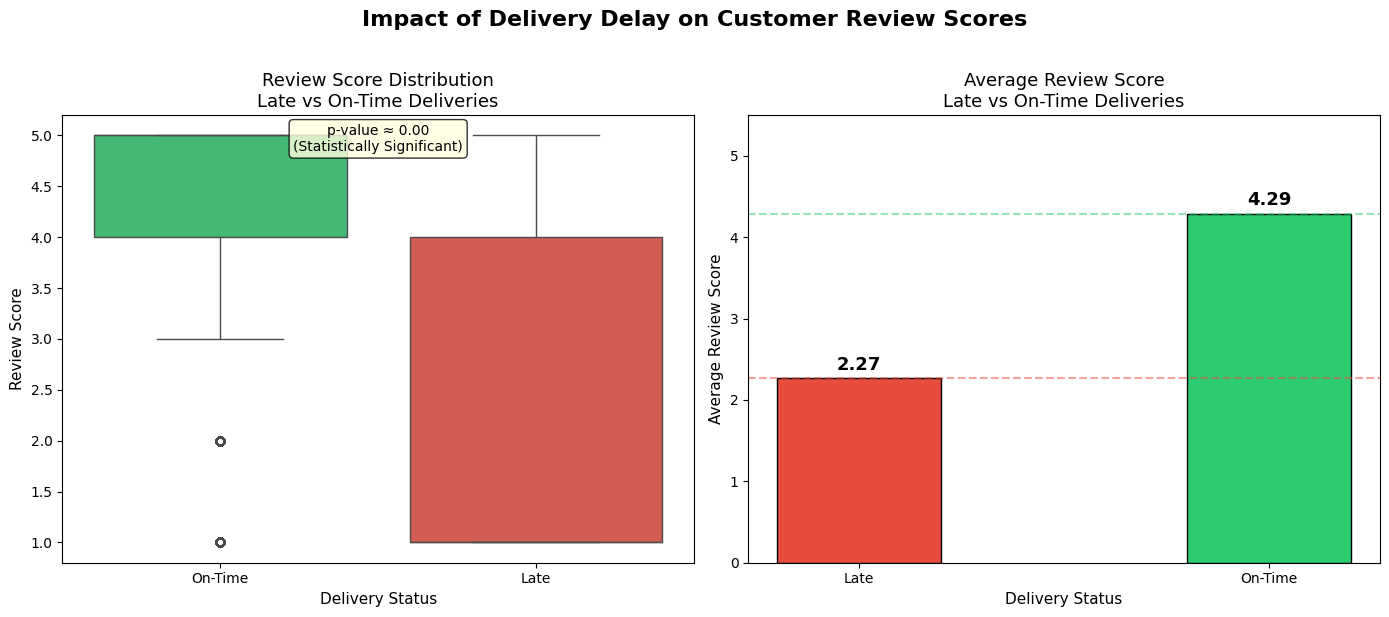

✅ Chart saved!


In [5]:
# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Impact of Delivery Delay on Customer Review Scores',
             fontsize=16, fontweight='bold', y=1.02)

# --- Plot 1: Box Plot ---
df['Delivery Status'] = df['is_late'].map({True: 'Late', False: 'On-Time'})

sns.boxplot(data=df, x='Delivery Status', y='review_score',
            palette={'Late': '#e74c3c', 'On-Time': '#2ecc71'}, ax=axes[0])
axes[0].set_title('Review Score Distribution\nLate vs On-Time Deliveries', fontsize=13)
axes[0].set_xlabel('Delivery Status', fontsize=11)
axes[0].set_ylabel('Review Score', fontsize=11)
axes[0].annotate('p-value ≈ 0.00\n(Statistically Significant)',
                 xy=(0.5, 0.92), xycoords='axes fraction',
                 ha='center', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Plot 2: Bar Chart of Average Scores ---
avg_scores = df.groupby('Delivery Status')['review_score'].mean().reset_index()
colors = ['#e74c3c' if x == 'Late' else '#2ecc71' for x in avg_scores['Delivery Status']]
bars = axes[1].bar(avg_scores['Delivery Status'], avg_scores['review_score'],
                   color=colors, width=0.4, edgecolor='black')
axes[1].set_title('Average Review Score\nLate vs On-Time Deliveries', fontsize=13)
axes[1].set_xlabel('Delivery Status', fontsize=11)
axes[1].set_ylabel('Average Review Score', fontsize=11)
axes[1].set_ylim(0, 5.5)

for bar, val in zip(bars, avg_scores['review_score']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', fontsize=13, fontweight='bold')

axes[1].axhline(y=4.29, color='#2ecc71', linestyle='--', alpha=0.5)
axes[1].axhline(y=2.27, color='#e74c3c', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('hypothesis_test_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

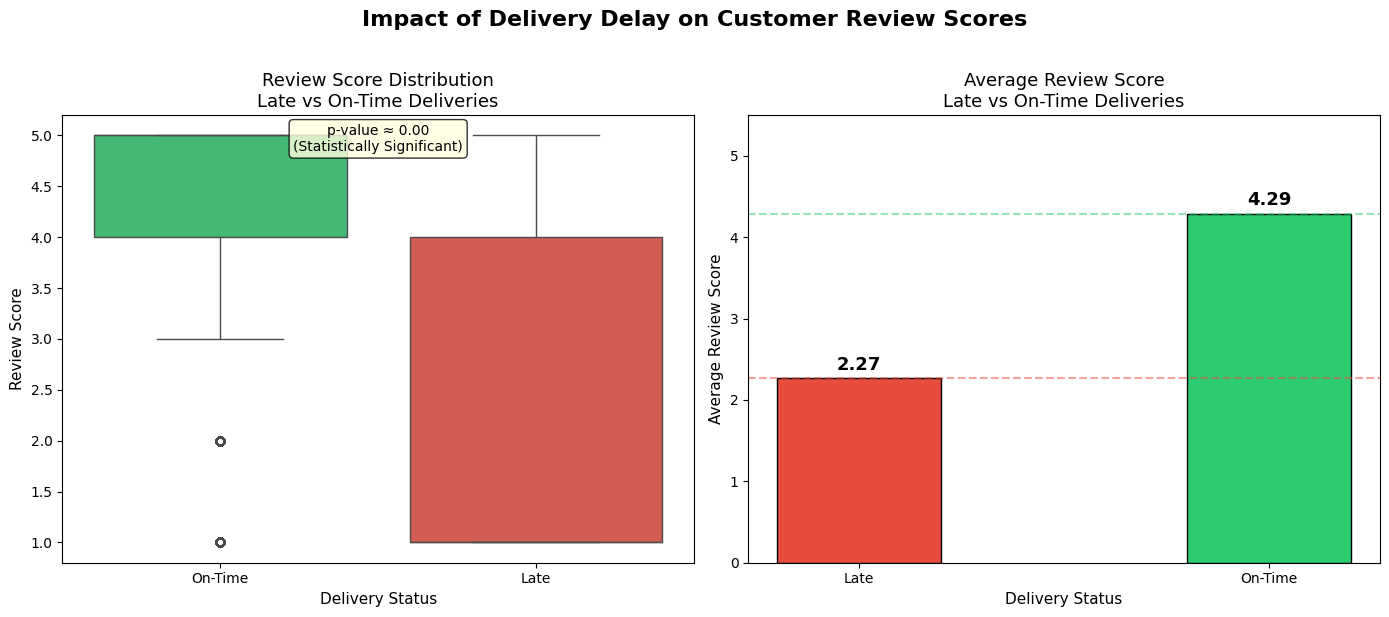

✅ Chart saved!


In [6]:
# --- Visualization (Fixed) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Impact of Delivery Delay on Customer Review Scores',
             fontsize=16, fontweight='bold', y=1.02)

# --- Plot 1: Box Plot (fixed) ---
df['Delivery Status'] = df['is_late'].map({True: 'Late', False: 'On-Time'})

sns.boxplot(data=df, x='Delivery Status', y='review_score',
            hue='Delivery Status',
            palette={'Late': '#e74c3c', 'On-Time': '#2ecc71'},
            legend=False, ax=axes[0])
axes[0].set_title('Review Score Distribution\nLate vs On-Time Deliveries', fontsize=13)
axes[0].set_xlabel('Delivery Status', fontsize=11)
axes[0].set_ylabel('Review Score', fontsize=11)
axes[0].annotate('p-value ≈ 0.00\n(Statistically Significant)',
                 xy=(0.5, 0.92), xycoords='axes fraction',
                 ha='center', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Plot 2: Bar Chart ---
avg_scores = df.groupby('Delivery Status')['review_score'].mean().reset_index()
colors = ['#e74c3c' if x == 'Late' else '#2ecc71' for x in avg_scores['Delivery Status']]
bars = axes[1].bar(avg_scores['Delivery Status'], avg_scores['review_score'],
                   color=colors, width=0.4, edgecolor='black')
axes[1].set_title('Average Review Score\nLate vs On-Time Deliveries', fontsize=13)
axes[1].set_xlabel('Delivery Status', fontsize=11)
axes[1].set_ylabel('Average Review Score', fontsize=11)
axes[1].set_ylim(0, 5.5)

for bar, val in zip(bars, avg_scores['review_score']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', fontsize=13, fontweight='bold')

axes[1].axhline(y=4.29, color='#2ecc71', linestyle='--', alpha=0.5)
axes[1].axhline(y=2.27, color='#e74c3c', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('hypothesis_test_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [7]:
# --- Save Hypothesis Testing Summary ---
summary = pd.DataFrame({
    'Metric': [
        'Total Orders Analyzed',
        'Late Orders',
        'On-Time Orders',
        'Avg Review Score (Late)',
        'Avg Review Score (On-Time)',
        'Difference in Score',
        'T-Statistic',
        'P-Value',
        'Significance Level',
        'Decision',
        'Business Conclusion'
    ],
    'Value': [
        len(df),
        df['is_late'].sum(),
        (~df['is_late']).sum(),
        round(late_scores.mean(), 2),
        round(ontime_scores.mean(), 2),
        round(ontime_scores.mean() - late_scores.mean(), 2),
        round(t_stat, 4),
        '< 0.0001 (essentially zero)',
        '0.05 (95% confidence)',
        'Reject Null Hypothesis',
        'Late deliveries cause significantly lower review scores'
    ]
})

summary.to_csv('hypothesis_testing_summary.csv', index=False)
print("✅ Summary saved!")
print(summary.to_string(index=False))

✅ Summary saved!
                    Metric                                                   Value
     Total Orders Analyzed                                                   96353
               Late Orders                                                    6409
            On-Time Orders                                                   89944
   Avg Review Score (Late)                                                    2.27
Avg Review Score (On-Time)                                                    4.29
       Difference in Score                                                    2.02
               T-Statistic                                               -132.0713
                   P-Value                             < 0.0001 (essentially zero)
        Significance Level                                   0.05 (95% confidence)
                  Decision                                  Reject Null Hypothesis
       Business Conclusion Late deliveries cause significantly lower r

In [8]:
from google.colab import files

files.download('hypothesis_testing_summary.csv')
files.download('hypothesis_test_visualization.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>